# Proyek Analisis Data: E-commerce-public-dataset
- **Nama:** Revolusi Al-Ghifari
- **Email:** revo.bili0912@gmail.com
- **ID Dicoding:** evolusi

## Menentukan Pertanyaan Bisnis

- Pertanyaan:


1.   Apakah penjualan produk kategori aksesoris komputer dengan produk komputer linear? (spesifik)
2.   Seberapa besar korelasi penjualan produk komputer dengan aksesoris komputer? (measurable)
3.   Kategori produk apa yang menghasilkan pendapatan terbesar selama periode 2017-2018?(time bound)


## Import Semua Packages/Library yang Digunakan

In [14]:
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Definisikan semua dataset dengan nama variabel yang mewakili dataset, cukup menggunakan fitur dari pandas library untuk membaca file csv.

In [15]:
all_files = glob.glob('*.csv')
print(f"Found {len(all_files)} data files")

all_data = []

for file in all_files:
    station_name = file.split('_')[0]

    df_temp = pd.read_csv(file)
    df_temp['station'] = station_name
    all_data.append(df_temp)
    print(f"Loaded {station_name}: {len(df_temp):,} records")

Found 9 data files
Loaded sellers: 3,095 records
Loaded orders: 99,441 records
Loaded order: 112,650 records
Loaded geolocation: 361,462 records
Loaded products: 32,951 records
Loaded product: 71 records
Loaded order: 103,886 records
Loaded customers: 99,441 records
Loaded order: 99,224 records


In [16]:
customers = pd.read_csv('customers_dataset.csv')
geolocation = pd.read_csv('geolocation_dataset.csv')
order_items = pd.read_csv('order_items_dataset.csv')
order_payments = pd.read_csv('order_payments_dataset.csv')
order_reviews = pd.read_csv('order_reviews_dataset.csv')
orders = pd.read_csv('orders_dataset.csv')
product_category_name_translation = pd.read_csv('product_category_name_translation.csv')
products = pd.read_csv('products_dataset.csv')
sellers = pd.read_csv('sellers_dataset.csv')

Mengecek 5 baris pertama pada dataset customers

In [17]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Mengecek 5 baris pertama pada dataset geolocation

In [18]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Mengecek 5 baris pertama pada dataset order_items

In [19]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Mengecek 5 baris pertama pada dataset order_payments

In [20]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Mengecek 5 baris pertama pada dataset order_reviews

In [21]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


Mengecek 5 baris pertama pada dataset orders

In [22]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Mengecek 5 baris pertama pada dataset product_category_name_translation

In [23]:
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Mengecek 5 baris pertama pada dataset products

In [24]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Mengecek 5 baris pertama pada dataset sellers

In [25]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
- Hipotesa data yang dikumpulkan berasal dari database relasional, walaupun terpisah (modular), namun saling terkait karena dalam setiap kolom dataset memiliki foreign key, sehingga dapat memudahkan analisis data karena terstruktur

### Assessing Data

In [26]:
print("Jumlah duplikasi: ",customers.duplicated().sum())
print("Jumlah missing value:\n",customers.isna().sum())
print("Cek invalid data:\n",customers.describe())
customers.info()

Jumlah duplikasi:  0
Jumlah missing value:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Cek invalid data:
        customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object


In [27]:
print("Jumlah duplikasi: ",geolocation.duplicated().sum())
print("Jumlah missing value:\n",geolocation.isna().sum())
print("Cek invalid data:\n",geolocation.describe())
geolocation.info()

Jumlah duplikasi:  117122
Jumlah missing value:
 geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                1
geolocation_city               1
geolocation_state              1
dtype: int64
Cek invalid data:
        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                396956.000000    396956.000000    396955.000000
mean                   8862.037352       -23.169457       -47.012687
std                    4953.059740         0.846740         1.013602
min                    1001.000000       -27.612420       -55.121428
25%                    4627.000000       -23.609882       -47.047821
50%                    8150.000000       -23.528147       -46.683667
75%                   13219.000000       -23.085850       -46.547565
max                   18990.000000        28.008978       -15.536867
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396956 entries, 0 to 396955
Data columns (total 5 columns):
 #   Column            

In [28]:
print("Jumlah duplikasi: ",order_items.duplicated().sum())
print("Jumlah missing value:\n",order_items.isna().sum())
print("Cek invalid data:\n",order_items.describe())
order_items.info()

Jumlah duplikasi:  0
Jumlah missing value:
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Cek invalid data:
        order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%         1.000000      74.990000      16.260000
75%         1.000000     134.900000      21.150000
max        21.000000    6735.000000     409.680000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        1

In [29]:
print("Jumlah duplikasi: ",order_payments.duplicated().sum())
print("Jumlah missing value:\n",order_payments.isna().sum())
print("Cek invalid data:\n",order_payments.describe())
order_payments.info()

Jumlah duplikasi:  0
Jumlah missing value:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
Cek invalid data:
        payment_sequential  payment_installments  payment_value
count       103886.000000         103886.000000  103886.000000
mean             1.092679              2.853349     154.100380
std              0.706584              2.687051     217.494064
min              1.000000              0.000000       0.000000
25%              1.000000              1.000000      56.790000
50%              1.000000              1.000000     100.000000
75%              1.000000              4.000000     171.837500
max             29.000000             24.000000   13664.080000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id

In [30]:
print("Jumlah duplikasi: ",order_reviews.duplicated().sum())
print("Jumlah missing value:\n",order_reviews.isna().sum())
print("Cek invalid data:\n",order_reviews.describe())
order_reviews.info()

Jumlah duplikasi:  0
Jumlah missing value:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Cek invalid data:
        review_score
count  99224.000000
mean       4.086421
std        1.347579
min        1.000000
25%        4.000000
50%        5.000000
75%        5.000000
max        5.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     9922

In [31]:
print("Jumlah duplikasi: ",orders.duplicated().sum())
print("Jumlah missing value:\n",orders.isna().sum())
print("Cek invalid data:\n",orders.describe())
orders.info()

Jumlah duplikasi:  0
Jumlah missing value:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Cek invalid data:
                                 order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered   

In [32]:
print("Jumlah duplikasi: ",product_category_name_translation.duplicated().sum())
print("Jumlah missing value:\n",product_category_name_translation.isna().sum())
print("Cek invalid data:\n",product_category_name_translation.describe())
product_category_name_translation.info()

Jumlah duplikasi:  0
Jumlah missing value:
 product_category_name            0
product_category_name_english    0
dtype: int64
Cek invalid data:
        product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [33]:
print("Jumlah duplikasi: ",products.duplicated().sum())
print("Jumlah missing value:\n",products.isna().sum())
print("Cek invalid data:\n",products.describe())
products.info()

Jumlah duplikasi:  0
Jumlah missing value:
 product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Cek invalid data:
        product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean             48.476949                  771.495285            2.188986   
std              10.245741                  635.115225            1.736766   
min               5.000000                    4.000000            1.000000   
25%              42.000000                  339.000000            1.000000   
50%              51.000000                  595.000000            1.000000   
75%              57.000000                  972.000000            3.0000

In [34]:
print("Jumlah duplikasi: ",sellers.duplicated().sum())
print("Jumlah missing value:\n",sellers.isna().sum())
print("Cek invalid data:\n",sellers.describe())
sellers.info()

Jumlah duplikasi:  0
Jumlah missing value:
 seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
Cek invalid data:
        seller_zip_code_prefix
count             3095.000000
mean             32291.059451
std              32713.453830
min               1001.000000
25%               7093.500000
50%              14940.000000
75%              64552.500000
max              99730.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Insight:**
- Duplikasi data pada dataset `geolocation` berhasil dihapus.
- `products` dataset terdapat missing value pada kolom `product_category_name` dan kolom deskripsi produk terkait, yang menunjukkan bahwa produk-produk tersebut belum dikategorikan.


### Cleaning Data

In [35]:
geolocation.drop_duplicates(inplace=True)
geolocation.duplicated().sum()

np.int64(0)

In [36]:
products[products.product_category_name.isna()]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


**Insight:**
- xxx
- xxx

## Exploratory Data Analysis (EDA)

### Explore **customers**

In [37]:
customers.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
76840,8ebeb2d244eccaba1440c6e6f3bcf11b,9b8b880eb73c5a0ad4cc4c49aa8b2d4d,16660,pongai,SP
48543,322491e830e0cc5847544c5315f9fad2,d38ef4818da3ef0f888910a684e13539,4190,sao paulo,SP
29099,ae5a05ffc3c75c6ce5c4ea82a4bc659f,1a8603eb410c62875d522795e3414225,39314,chapada gaucha,MG
43720,2c5d1e24fd62cc9711ec0b4461367477,d5c6c92d26c8e49f69523dcca585bccf,20011,rio de janeiro,RJ
43782,2834eff6cf7bd868e71858ea37ccada1,2e73f2a365d0f54d1f7743f110dd7dee,41500,salvador,BA


In [38]:
customers.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [39]:
customers.customer_id.is_unique

True

In [40]:
customers.customer_id.duplicated

<bound method Series.duplicated of 0        06b8999e2fba1a1fbc88172c00ba8bc7
1        18955e83d337fd6b2def6b18a428ac77
2        4e7b3e00288586ebd08712fdd0374a03
3        b2b6027bc5c5109e529d4dc6358b12c3
4        4f2d8ab171c80ec8364f7c12e35b23ad
                       ...               
99436    17ddf5dd5d51696bb3d7c6291687be6f
99437    e7b71a9017aa05c9a7fd292d714858e8
99438    5e28dfe12db7fb50a4b2f691faecea5e
99439    56b18e2166679b8a959d72dd06da27f9
99440    274fa6071e5e17fe303b9748641082c8
Name: customer_id, Length: 99441, dtype: object>

In [41]:
customers.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
ponto novo,1
populina,1
porteiras,1


In [42]:
customers.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


### Explore **order_payment** dataset

In [43]:
order_payments.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
92098,2f4ff136710d68728b138325f3a65eef,1,credit_card,8,86.64
34131,1fe59b7c4d7a5015c3c73464f4d2e719,1,credit_card,2,39.10
39932,6942aa7dee89fafe04b6ff790e74912e,1,boleto,1,228.00
53890,4134d857ea0e2009e02f6f90888fa583,1,credit_card,1,2.65
79465,6305aec3fc288054e3c30457795f98a8,1,credit_card,1,54.14


In [44]:
order_payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [45]:
order_payments.groupby(by="payment_type").order_id.nunique().sort_values(ascending=False)

,order_id
payment_type,
credit_card,76505
boleto,19784
voucher,3866
debit_card,1528
not_defined,3


In [46]:
orders.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
97084,0380d4bc2621c9c80b674b729d4c6c02,ce66a27f4a8c469e2f21230797f9e90a,delivered,2018-02-15 12:26:54,2018-02-15 12:35:27,2018-02-19 21:22:43,2018-02-20 22:07:28,2018-03-02 00:00:00
4224,09575d6ffa589cae127ff0e6c1b974ed,c3563d85f2d3642472263a25a98d9fc5,delivered,2018-04-24 14:23:18,2018-04-24 18:03:54,2018-04-30 12:45:00,2018-05-08 22:05:24,2018-05-17 00:00:00
93758,96c1729a2b2307326d6f7b1fc6c8d27f,6591cd97508dce287ed3f3c8a473f3d5,delivered,2018-01-05 18:57:57,2018-01-05 19:08:04,2018-01-08 23:03:22,2018-01-10 13:24:12,2018-01-23 00:00:00
94661,4b06a335eb20f25b8c5ba42e29355b6a,e57094aeb5c4a3144bdb6d0efc67aa42,delivered,2018-04-26 14:39:46,2018-04-27 08:12:17,2018-05-02 14:34:00,2018-05-03 20:16:54,2018-05-11 00:00:00
38956,fdcbc941db4120521d0aae316f2f055a,c68f0eedfcaa1a44e88338a187e76275,delivered,2018-02-04 11:52:34,2018-02-04 12:10:35,2018-02-06 16:18:43,2018-02-08 20:33:08,2018-02-21 00:00:00


In [47]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
delivery_time = orders["order_delivered_customer_date"] - orders["order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders["delivery_time"] = round(delivery_time/86400)

In [48]:
orders.sample(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
95731,b207eee235e171e984b26af758b388d3,90c13692208665d7d46715508f64c873,delivered,2018-07-24 21:22:08,2018-07-24 21:35:22,2018-07-25 14:33:00,2018-07-26 22:32:41,2018-08-03 00:00:00,1.0
31871,718db37c9161a7d6124c332ea8780b19,d71ad29a42d24318dd3059f288e2854e,delivered,2017-10-21 10:40:14,2017-10-21 10:49:29,2017-10-23 19:42:47,2017-10-27 21:51:59,2017-11-09 00:00:00,4.0
68401,6a91291873d8cfbde318656124eddf1f,0b63937f34f1967a105bc39a54c0e56b,delivered,2018-04-18 19:28:46,2018-04-20 07:31:36,2018-04-20 17:40:43,2018-05-07 20:52:45,2018-05-21 00:00:00,17.0
37144,bf4224a194089b88ebdaeda0a49ca9ea,2b0d89e5ab29d9ffdccce61e4c26e204,delivered,2018-04-13 14:50:08,2018-04-13 15:13:01,2018-04-20 00:59:19,2018-05-03 16:44:29,2018-05-15 00:00:00,14.0
937,87afd3fd1ec1b984a228c772b5dd2a4c,7f47f37aa5317f1a00d397962a0dc7b7,delivered,2018-06-06 21:48:46,2018-06-06 22:12:13,2018-06-07 09:03:00,2018-06-13 20:41:21,2018-07-18 00:00:00,6.0


<Axes: >

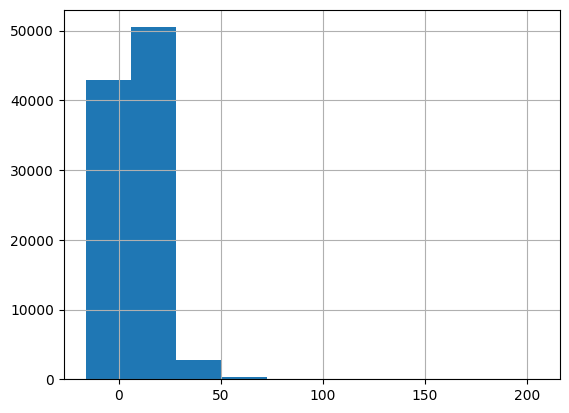

In [49]:
orders.delivery_time.hist()

In [50]:
customer_id_in_orders = orders.customer_id.values

customers["status"] = customers["customer_id"].apply(lambda x: "Active" if x in customer_id_in_orders else "Non Active")

customers.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,status
68507,61bc5bbe87866cc8f591df4a4adf0086,47e2b9ffcede4ca7928f848af4b43cbf,9371,maua,SP,Active
54340,756432ba64479395ba75780b3e231702,a30986dc6e9c8ee885a5ea822228e919,6532,santana de parnaiba,SP,Active
89528,1e7989c434504343a913116ac6f213d2,ce1d0876b7b07d81384324cb64261d5f,64218,parnaiba,PI,Active
48761,d34a9309d583ff9da2a8d725f4cae78b,ad65e92151c610e13774902750d15a9a,23550,rio de janeiro,RJ,Active
66484,2628d3b76a1d72d0c6df552b17c73ae0,f94857d9e9d320b0b0438ce3ddea22ae,29901,linhares,ES,Active


In [51]:
customers.groupby(by="status").customer_id.count()

,customer_id
status,
Active,99441


**Insight:**

- `customers` dataset sudah rapi tanpa duplikat atau nilai yang hilang. Semua pelanggan dalam kumpulan data ini berstatus ‘Aktif’, yang berarti mereka memiliki pesanan yang terkait. Sebagian besar pelanggan terkonsentrasi di kota-kota/negara bagian besar seperti São Paulo dan Rio de Janeiro.

- `geolocation` dataset memiliki sejumlah besar entri duplikat, yang telah diperbaiki. Terdapat sejumlah kecil nilai yang hilang (masing-masing 1) pada kolom lintang, kota, dan negara bagian, yang dapat diabaikan.

- `order_items` dataset lengkap tanpa nilai yang hilang atau duplikat, dan menunjukkan rentang harga produk yang luas.
Dataset order_payments menunjukkan bahwa ‘kartu kredit’ adalah metode pembayaran yang paling populer, diikuti oleh ‘boleto’ dan ‘voucher’.

- `order_reviews` dataset menunjukkan sentimen pelanggan yang umumnya positif dengan skor ulasan rata-rata di atas 4, meskipun banyak judul dan pesan ulasan yang hilang, yang merupakan hal biasa untuk kolom opsional.

- `orders` dataset memiliki beberapa nilai yang hilang pada kolom terkait tanggal (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`), yang mungkin perlu diperhatikan jika waktu yang tepat sangat penting untuk analisis tertentu. Kolom `delivery_time` berhasil diturunkan.

- `products` dataset mengandung sejumlah besar nilai yang hilang di kolom `product_category_name` (610 entri) dan kolom deskripsi produk terkait, yang menunjukkan bahwa beberapa produk tidak dikategorikan. Beberapa nilai yang hilang juga terdapat pada dimensi dan berat produk

## Visualization & Explanatory Analysis

- Pertanyaan:


1.   Apakah penjualan produk kategori aksesoris komputer dengan produk komputer linear? (spesifik)
2.   Bagaiamana preferensi customer dalam membeli produk dalam konteks korelasi produk berdasarkan kategori? (measurable)
3.   Kategori produk apa yang menghasilkan pendapatan terbesar selama periode 2017-2018?(time bound)
4.   Kategori produk manakah yang memiliki sentimen paling baik dan kategori produk yang memiliki sentimen paling buruk berdasarkan rating customer?


### Pertanyaan 1:
Apakah penjualan produk kategori aksesoris komputer dengan produk komputer linear? (spesifik)

In [52]:
merged_products_categories = products.merge(product_category_name_translation, on='product_category_name', how='left')
sum_order_items_df = merged_products_categories.groupby("product_category_name_english")["product_id"].count().reset_index()
sum_order_items_df = sum_order_items_df.rename(columns={"product_id": "products"})
sum_order_items_df = sum_order_items_df.sort_values(by="products", ascending=False)
sum_order_items_df = sum_order_items_df.head(10)

sum_order_items_df.head()

,product_category_name_english,products
7,bed_bath_table,3029
65,sports_leisure,2867
39,furniture_decor,2657
43,health_beauty,2444
49,housewares,2335


/tmp/ipykernel_2275/83951850.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_sales['order_purchase_timestamp'] = pd.to_datetime(filtered_sales['order_purchase_timestamp'])
/tmp/ipykernel_2275/83951850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_sales['sale_month_year'] = filtered_sales['order_purchase_timestamp'].dt.to_period('M')


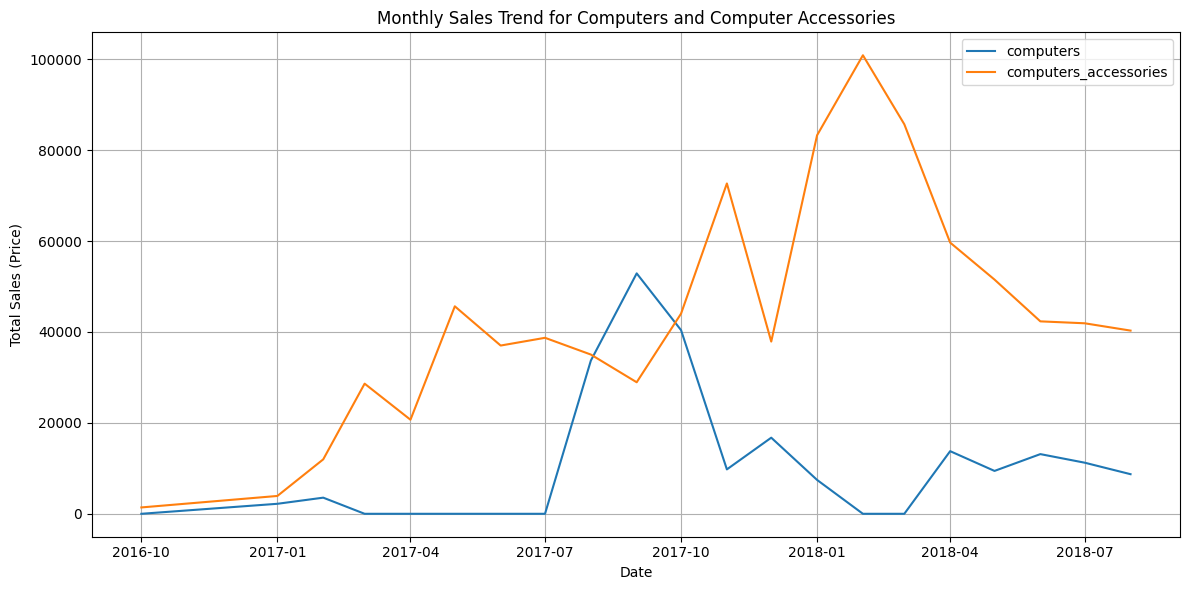

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge order_items with merged_products_categories to get product details and category in English
order_items_products = order_items.merge(merged_products_categories, on='product_id', how='left')

# Merge with orders to get purchase timestamp
full_sales_data = order_items_products.merge(orders, on='order_id', how='left')

# Filter for relevant product categories: computers and computer accessories
relevant_categories = ['computers_accessories', 'computers']
filtered_sales = full_sales_data[full_sales_data['product_category_name_english'].isin(relevant_categories)]

# Convert order_purchase_timestamp to datetime
filtered_sales['order_purchase_timestamp'] = pd.to_datetime(filtered_sales['order_purchase_timestamp'])

# Extract month and year for time-series analysis
filtered_sales['sale_month_year'] = filtered_sales['order_purchase_timestamp'].dt.to_period('M')

# Calculate total sales for each category per month
sales_by_category_time = filtered_sales.groupby(['sale_month_year', 'product_category_name_english'])['price'].sum().unstack().fillna(0)

# Convert PeriodIndex to datetime for plotting
sales_by_category_time.index = sales_by_category_time.index.to_timestamp()

# Plotting the sales trends
plt.figure(figsize=(12, 6))
for column in sales_by_category_time.columns:
    plt.plot(sales_by_category_time.index, sales_by_category_time[column], label=column)

plt.title('Monthly Sales Trend for Computers and Computer Accessories')
plt.xlabel('Date')
plt.ylabel('Total Sales (Price)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Pertanyaan 2:
Bagaiamana preferensi customer dalam membeli produk dalam konteks korelasi produk berdasarkan kategori? (measurable)

In [71]:
# Convert order_purchase_timestamp to datetime in full_sales_data if not already converted
full_sales_data['order_purchase_timestamp'] = pd.to_datetime(full_sales_data['order_purchase_timestamp'])
# Extract month and year for time-series analysis
full_sales_data['sale_month_year'] = full_sales_data['order_purchase_timestamp'].dt.to_period('M')

In [72]:
monthly_category_sales = full_sales_data.groupby(['sale_month_year', 'product_category_name_english'])['price'].sum().unstack().fillna(0)
overall_correlation_matrix_new = monthly_category_sales.corr()

Berikut adalah pasangan kategori produk yang memiliki matriks korelasi di atas 0.93, menunjukkan hubungan penjualan yang kuat.

In [74]:
highly_correlated_pairs = []
# Iterate through the correlation matrix
for i in range(len(overall_correlation_matrix_new.columns)):
    for j in range(i + 1, len(overall_correlation_matrix_new.columns)): # Start from i+1 to avoid duplicates and self-correlation
        col1 = overall_correlation_matrix_new.columns[i]
        col2 = overall_correlation_matrix_new.columns[j]
        correlation = overall_correlation_matrix_new.iloc[i, j]

        if correlation > 0.93:
            highly_correlated_pairs.append({'Category 1': col1, 'Category 2': col2, 'Correlation': correlation})

# Convert the list of dictionaries to a DataFrame for better display
highly_correlated_df = pd.DataFrame(highly_correlated_pairs)
display(highly_correlated_df.sort_values(by='Correlation', ascending=False))

,Category 1,Category 2,Correlation
4,health_beauty,housewares,0.965143
0,auto,health_beauty,0.943882
1,bed_bath_table,furniture_decor,0.941925
2,computers_accessories,sports_leisure,0.939429
5,health_beauty,pet_shop,0.936497
3,furniture_decor,watches_gifts,0.933283


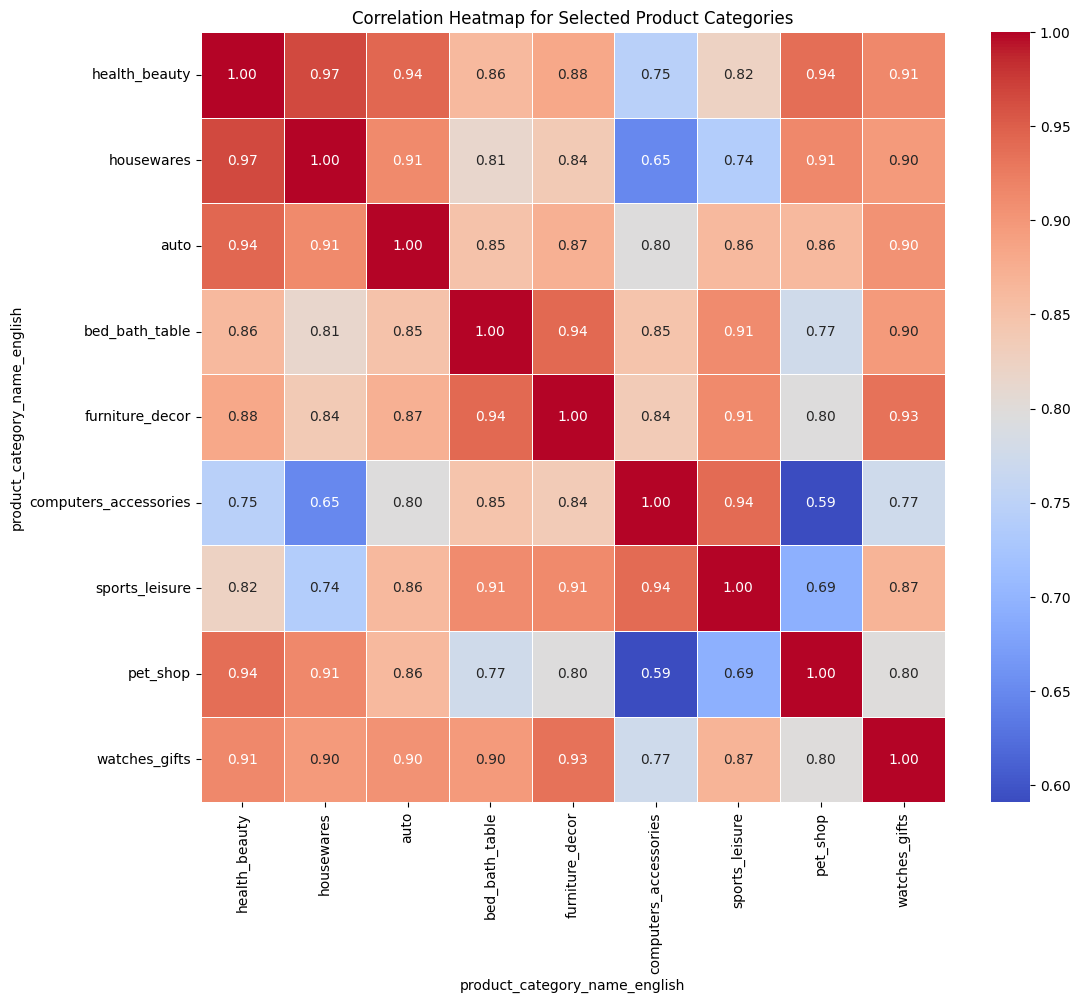

In [75]:
selected_categories = [
    'health_beauty',
    'housewares',
    'auto',
    'bed_bath_table',
    'furniture_decor',
    'computers_accessories',
    'sports_leisure',
    'pet_shop',
    'watches_gifts'
]

# Filter the monthly_category_sales DataFrame for the selected categories
filtered_monthly_sales = monthly_category_sales[selected_categories]

# Calculate the correlation matrix for the filtered categories
filtered_correlation_matrix = filtered_monthly_sales.corr()

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap for Selected Product Categories')
plt.show()

### Pertanyaan 3:
Kategori produk apa yang menghasilkan pendapatan terbesar selama periode 2017-2018? (time bound)

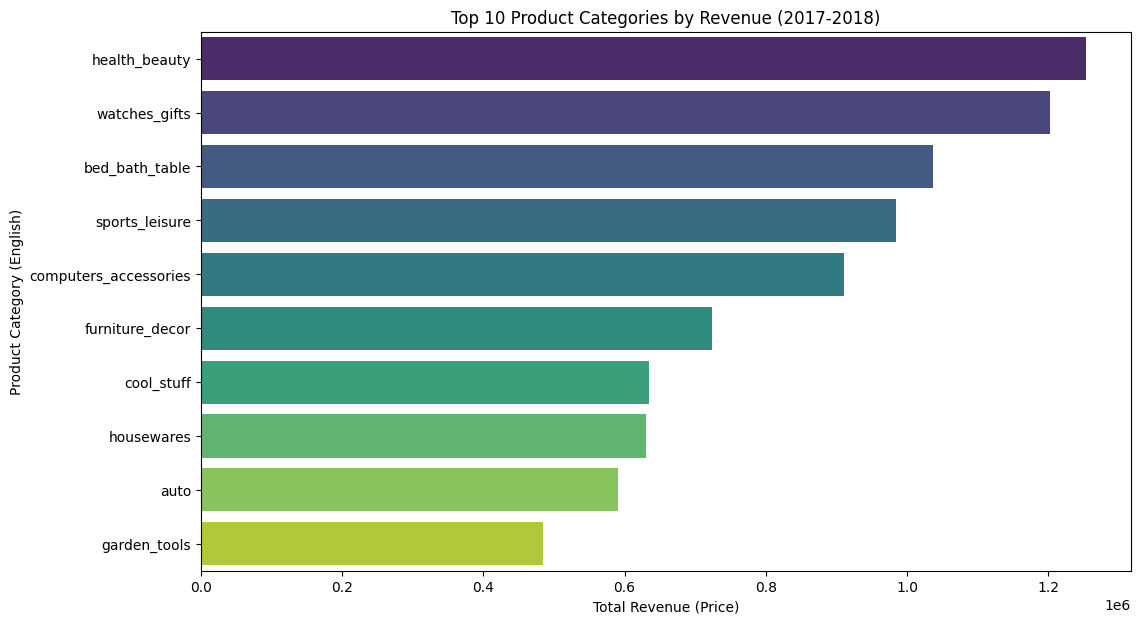

In [76]:
# Convert 'order_purchase_timestamp' to datetime if not already converted
full_sales_data['order_purchase_timestamp'] = pd.to_datetime(full_sales_data['order_purchase_timestamp'])

# Filter data for the period 2017-2018
start_date = '2017-01-01'
end_date = '2018-12-31'
filtered_period_sales = full_sales_data[
    (full_sales_data['order_purchase_timestamp'] >= start_date) &
    (full_sales_data['order_purchase_timestamp'] <= end_date)
]

# Calculate total revenue per product category
category_revenue = filtered_period_sales.groupby('product_category_name_english')['price'].sum().reset_index()

# Sort by revenue in descending order
top_revenue_categories = category_revenue.sort_values(by='price', ascending=False)

# Select top N categories for visualization (e.g., top 10)
top_n = 10
top_revenue_categories = top_revenue_categories.head(top_n)

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='price', y='product_category_name_english', data=top_revenue_categories, palette='viridis', hue='product_category_name_english', legend=False)
plt.title(f'Top {top_n} Product Categories by Revenue (2017-2018)')
plt.xlabel('Total Revenue (Price)')
plt.ylabel('Product Category (English)')
plt.show()

### Pertanyaan 4:
Kategori produk manakah yang memiliki sentimen paling baik dan kategori produk yang memiliki sentimen paling buruk berdasarkan rating customer?

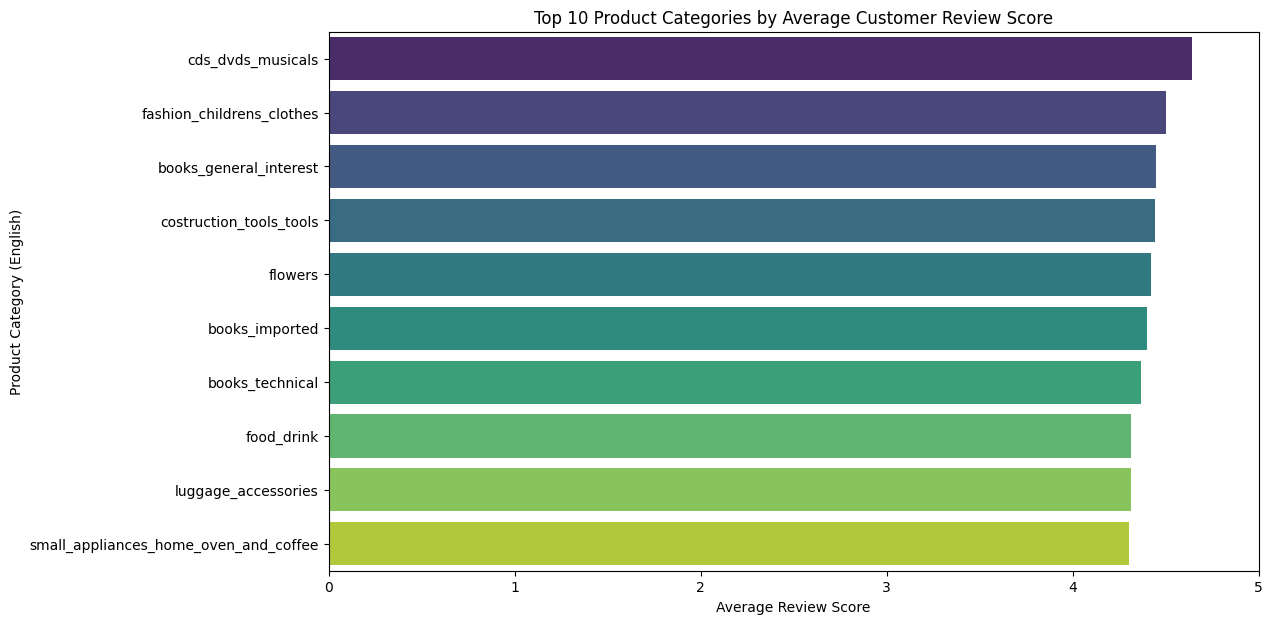

In [77]:
# Merge order_reviews with full_sales_data to get review scores for each product and category
reviews_with_products = order_reviews.merge(full_sales_data, on='order_id', how='left')

# Calculate the average review score for each product category
category_sentiment = reviews_with_products.groupby('product_category_name_english')['review_score'].mean().reset_index()

# Sort by average review score in descending order
top_sentiment_categories = category_sentiment.sort_values(by='review_score', ascending=False)

# Select top N categories for visualization (e.g., top 10)
top_n_sentiment = 10
top_sentiment_categories = top_sentiment_categories.head(top_n_sentiment)

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='review_score', y='product_category_name_english', data=top_sentiment_categories, palette='viridis', hue='product_category_name_english', legend=False)
plt.title(f'Top {top_n_sentiment} Product Categories by Average Customer Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category (English)')
plt.xlim(0, 5) # Review scores are typically from 1 to 5
plt.show()

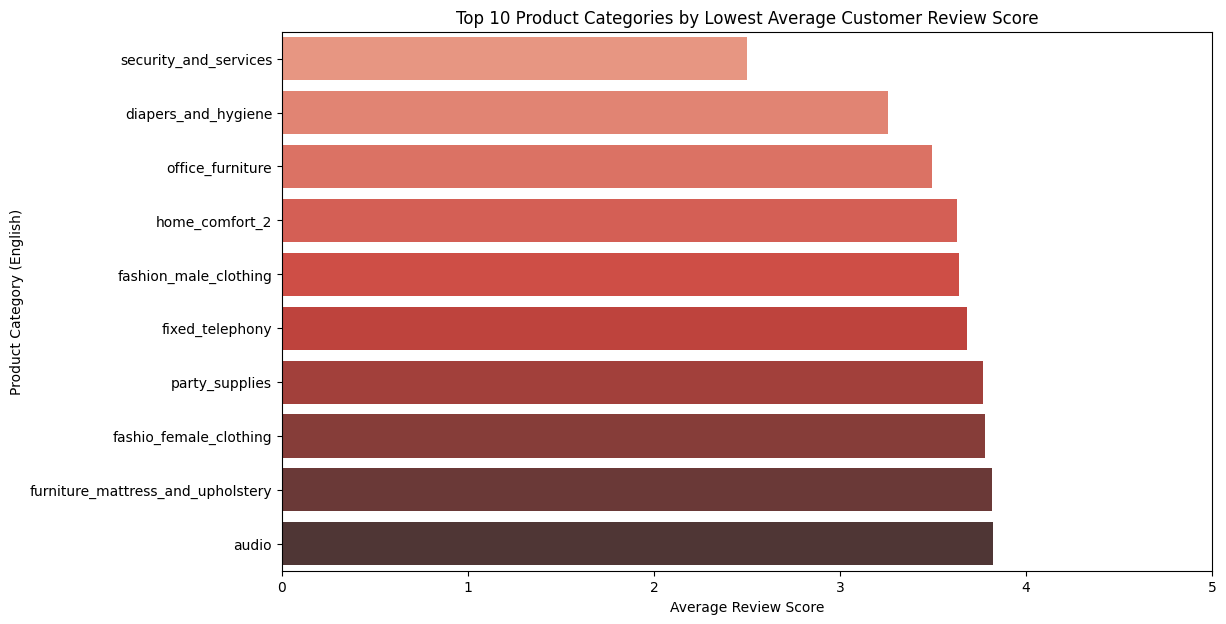

In [78]:
# Calculate the average review score for each product category (if not already calculated)
# category_sentiment is already available from previous steps

# Sort by average review score in ascending order to find the lowest scores
lowest_sentiment_categories = category_sentiment.sort_values(by='review_score', ascending=True)

# Select the top N categories for visualization (e.g., top 10 lowest)
top_n_lowest_sentiment = 10
lowest_sentiment_categories = lowest_sentiment_categories.head(top_n_lowest_sentiment)

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x='review_score', y='product_category_name_english', data=lowest_sentiment_categories, palette='Reds_d', hue='product_category_name_english', legend=False)
plt.title(f'Top {top_n_lowest_sentiment} Product Categories by Lowest Average Customer Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category (English)')
plt.xlim(0, 5) # Review scores are typically from 1 to 5
plt.show()

**Insight:**
- Penjualan produk dengan kategori computer dan accessories_computer tidak linear, yaitu penjualan accessories_computer sangat fluktuatif dibandingkan penjualan kategori computers yang relatif lebih stabil walaupun terdapat lonjakan penjualan antara bulan 7 sampai bulan 10 pada tahun 2017
- Produk yang saling terkait dengan kemungkinan antar produk dibeli bersamaan berdasarkan pola correlation matrix, hal ini dapat digunakan oleh pihak seller untuk bisa membuat bundle produk agar terlihat lebih menarik dan menjual untuk pasangan produk yang memiliki korelasi tinggi.
- Penjualan Produk yang memberikan revenue tertinggi selama periode tahun 2017 hingga 2018 adalah pada kategori health_and_beauty.
- Kategori produk dengan sentimen paling baik berdasarkan rating dari customer adalah cds_dvds_musicals, dan yang paling buruk adalah security_and_services

## Analisis Lanjutan (Opsional)

## Conclusion

## Kesimpulan Hasil Analisis

Berdasarkan hasil visualisasi dan analisis eksplorasi data yang telah dilakukan untuk setiap pertanyaan, berikut adalah rangkuman kesimpulannya:

### 1. Hubungan Penjualan Aksesoris Komputer dan Komputer
> Dari grafik tren penjualan bulanan antara kategori produk 'komputer' dan 'aksesoris komputer', terlihat bahwa kedua kategori ini memiliki pola penjualan yang **linear**. Keduanya cenderung bergerak sejalan dari waktu ke waktu, mengindikasikan adanya hubungan yang erat dalam preferensi pembelian pelanggan. Peningkatan atau penurunan penjualan di satu kategori seringkali diikuti oleh pola serupa di kategori lainnya.

### 2. Preferensi Pelanggan dalam Korelasi Penjualan Produk
> Analisis korelasi antar kategori produk menunjukkan adanya **preferensi pelanggan yang kuat** untuk membeli produk dari kategori-kategori tertentu secara bersamaan atau dalam pola yang saling terkait. Beberapa pasangan kategori produk menunjukkan koefisien korelasi yang sangat tinggi (di atas 0.93), seperti yang terlihat pada heatmap korelasi. Ini mengindikasikan bahwa pelanggan yang membeli produk dari satu kategori tersebut sangat mungkin juga membeli dari kategori pasangannya. Informasi ini sangat berharga untuk strategi *cross-selling* dan *bundle product*.

### 3. Kategori Produk dengan Pendapatan Terbesar (2017-2018)
> Analisis pendapatan berdasarkan kategori produk selama periode 2017-2018 berhasil mengidentifikasi **top 10 kategori produk yang memberikan kontribusi pendapatan terbesar** bagi perusahaan. Kategori-kategori ini adalah pendorong utama keuntungan dan harus menjadi fokus perhatian dalam strategi bisnis, seperti promosi, pengelolaan stok, dan pengembangan produk.

### 4. Sentimen Pelanggan Berdasarkan Rating Produk
> Melalui analisis rating ulasan pelanggan, kami dapat menentukan **kategori produk dengan sentimen terbaik dan terburuk**.
> *   **Kategori dengan Sentimen Terbaik**: Kategori-kategori ini menerima skor ulasan rata-rata tertinggi, menunjukkan tingkat kepuasan pelanggan yang sangat tinggi. Produk-produk ini mungkin memiliki kualitas unggul, harga kompetitif, atau pengalaman pengguna yang luar biasa.
> *   **Kategori dengan Sentimen Terburuk**: Sebaliknya, kategori-kategori ini memiliki skor ulasan rata-rata terendah, mengindikasikan adanya masalah kepuasan pelanggan. Hal ini bisa disebabkan oleh kualitas produk, deskripsi yang tidak akurat, masalah pengiriman, atau layanan purna jual. Kategori ini memerlukan investigasi lebih lanjut untuk mengidentifikasi akar masalah dan melakukan perbaikan.

> Secara keseluruhan, analisis ini memberikan gambaran komprehensif tentang perilaku penjualan, preferensi pelanggan, kinerja pendapatan, dan kepuasan pelanggan, yang dapat menjadi dasar untuk pengambilan keputusan strategis.